# **Task 51**

**Linear Regression**

Predict continuous values by fitting a line to data.

Slope: -1.7512877115526118
Intercept: 103.10596026490066
R-value: -0.758591524376155


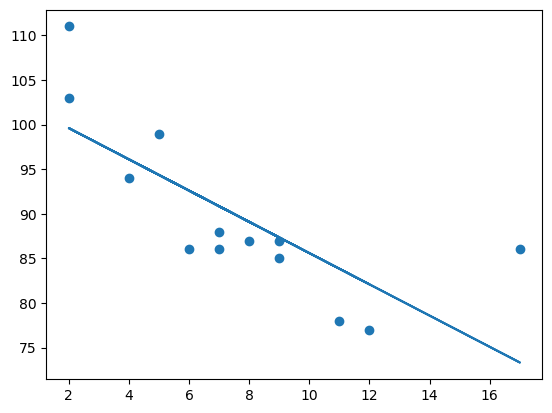

Predicted speed for age 10: 85.59308314937454
sklearn prediction: [85.59308315]


In [1]:
import matplotlib.pyplot as plt
from scipy import stats

x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

slope, intercept, r, p, std_err = stats.linregress(x, y)

print("Slope:", slope)
print("Intercept:", intercept)
print("R-value:", r)   # closer to 1/-1 = better fit

def myfunc(x):
    return slope * x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

# Predict for x=10
speed = myfunc(10)
print("Predicted speed for age 10:", speed)

# --- Using scikit-learn ---
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array(x).reshape(-1, 1)
Y = np.array(y)

model = LinearRegression()
model.fit(X, Y)
print("sklearn prediction:", model.predict([[10]]))

# **Task 52**

**Logistic Regression**

Binary classification — predicts probabilities between 0 and 1.



In [2]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load digits dataset (MNIST-like)
digits = datasets.load_digits()

X = digits.data
y = digits.target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", model.score(X_test, y_test))

# --- Simple binary example ---
X2 = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y2 = np.array([0,0,0,0,1,1,1,1,1,1])

lr = LogisticRegression()
lr.fit(X2, y2)
print("Predict 6:", lr.predict([[6]]))

[[27  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  1  0]
 [ 0  0 35  1  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  0  0  0 29  0  0  1  0  0]
 [ 0  0  0  0  0 38  0  0  0  2]
 [ 0  1  0  0  0  0 43  0  0  0]
 [ 0  0  0  0  1  0  0 38  0  0]
 [ 0  2  1  0  0  0  0  0 36  0]
 [ 0  0  0  0  0  1  0  0  0 40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.92      0.97      0.94        35
           2       0.97      0.97      0.97        36
           3       0.97      1.00      0.98        29
           4       0.97      0.97      0.97        30
           5       0.97      0.95      0.96        40
           6       1.00      0.98      0.99        44
           7       0.97      0.97      0.97        39
           8       0.97      0.92      0.95        39
           9       0.95      0.98      0.96        41

    accuracy                           0.97       360
   macro avg       

# **Task 53**

**Decession Tree**

Tree-based classifier that splits data on feature thresholds.

Predict age 20: [1]
Predict age 13: [0]


c:\Users\Mushahid Bashir\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Mushahid Bashir\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


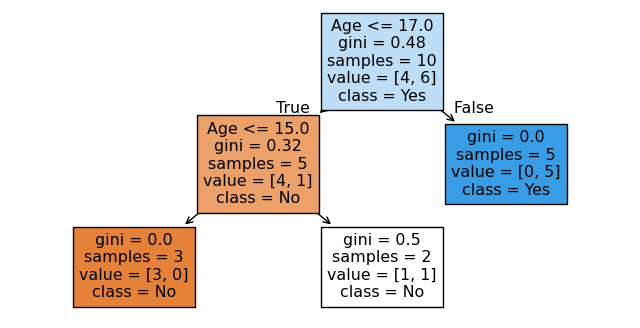

Iris accuracy: 0.9555555555555556


In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Simple dataset
dataset = {
  'Age':     [10,12,14,16,16,18,20,22,22,24],
  'Go':      ['No','No','No','Yes','No','Yes','Yes','Yes','Yes','Yes']
}
df = pd.DataFrame(dataset)

# Encode target
df['Go'] = df['Go'].map({'Yes':1, 'No':0})

X = df[['Age']]
y = df['Go']

clf = DecisionTreeClassifier()
clf.fit(X, y)

print("Predict age 20:", clf.predict([[20]]))
print("Predict age 13:", clf.predict([[13]]))

# Visualize
fig, ax = plt.subplots(figsize=(8,4))
tree.plot_tree(clf, feature_names=['Age'],
               class_names=['No','Yes'], filled=True, ax=ax)
plt.show()

# --- Iris dataset example ---
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = datasets.load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=1)

clf2 = DecisionTreeClassifier(criterion='entropy')
clf2.fit(X_train, y_train)
y_pred = clf2.predict(X_test)
print("Iris accuracy:", accuracy_score(y_test, y_pred))

# **Task 54**

**Support Vector Machine**

Find the optimal hyperplane to separate classes.

Linear SVM accuracy: 1.0
RBF SVM accuracy: 1.0
Poly SVM accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



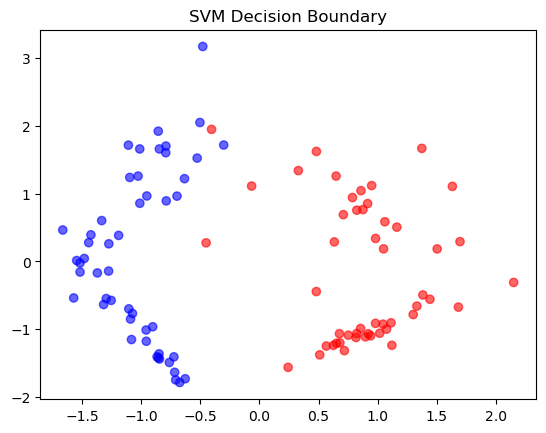

In [4]:
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Linear kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
print("Linear SVM accuracy:", svm_linear.score(X_test, y_test))

# RBF (Gaussian) kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
print("RBF SVM accuracy:", svm_rbf.score(X_test, y_test))

# Polynomial kernel
svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train, y_train)
print("Poly SVM accuracy:", svm_poly.score(X_test, y_test))

print(classification_report(y_test, svm_rbf.predict(X_test)))

# --- 2D visualization ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X2, y2 = make_classification(n_features=2, n_redundant=0,
                              n_informative=2, random_state=1)
clf = SVC(kernel='linear')
clf.fit(X2, y2)

plt.scatter(X2[:,0], X2[:,1], c=y2, cmap='bwr', alpha=0.6)
plt.title("SVM Decision Boundary")
plt.show()

# **Task 55**

**Time Series Analysis**

Analyze and forecast time-based data using Pandas.

2020-01-01    50.496714
2020-01-02    50.358450
2020-01-03    51.006138
2020-01-04    52.529168
2020-01-05    52.295015
Freq: D, dtype: float64


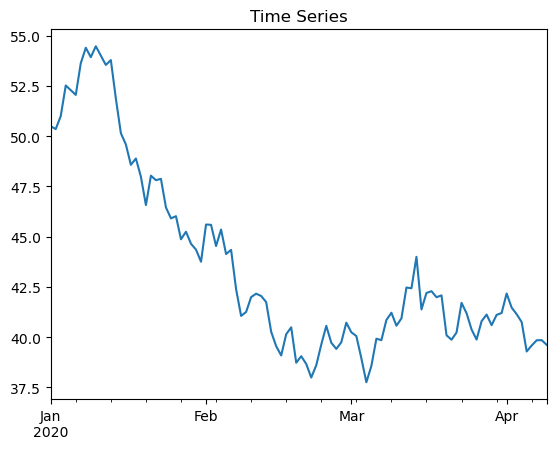

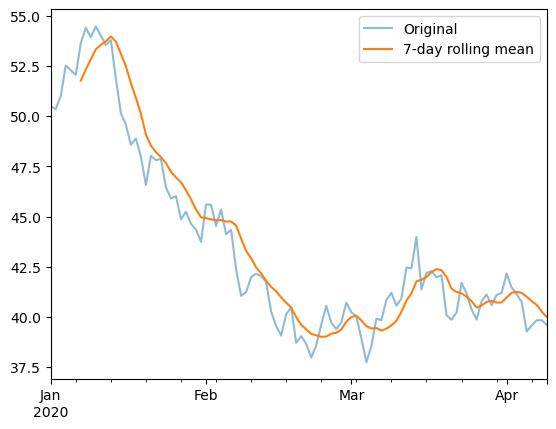

2020-01-31    49.523935
2020-02-29    41.192895
2020-03-31    40.836320
2020-04-30    40.413318
Freq: ME, dtype: float64
             original       lag1
2020-01-01  50.496714        NaN
2020-01-02  50.358450  50.496714
2020-01-03  51.006138  50.358450
2020-01-04  52.529168  51.006138
2020-01-05  52.295015  52.529168
2020-01-06  52.060878  52.295015
2020-01-07  53.640091  52.060878
2020-01-08  54.407525  53.640091
2020-01-09  53.938051  54.407525
2020-01-10  54.480611  53.938051
Next 10 day forecast: [37.12727563 36.9992055  36.87113536 36.74306522 36.61499509 36.48692495
 36.35885481 36.23078468 36.10271454 35.9746444 ]


C:\Users\Mushahid Bashir\AppData\Local\Temp\ipykernel_16900\2220899796.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = ts.resample('M').mean()


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load time series CSV (use any date-indexed data)
# df = pd.read_csv('data.csv', index_col='date', parse_dates=True)

# Create synthetic time series
import numpy as np
dates = pd.date_range('2020-01-01', periods=100, freq='D')
np.random.seed(42)
values = np.cumsum(np.random.randn(100)) + 50
ts = pd.Series(values, index=dates)

print(ts.head())

# Plot
ts.plot(title='Time Series')
plt.show()

# Rolling mean (smoothing)
rolling_mean = ts.rolling(window=7).mean()
ts.plot(label='Original', alpha=0.5)
rolling_mean.plot(label='7-day rolling mean')
plt.legend()
plt.show()

# Resampling — monthly mean
monthly = ts.resample('M').mean()
print(monthly)

# Shift — lag feature
ts_lag = ts.shift(1)
print(pd.DataFrame({'original': ts, 'lag1': ts_lag}).head(10))

# Basic forecasting with linear regression
from sklearn.linear_model import LinearRegression
X = np.arange(len(ts)).reshape(-1,1)
y = ts.values
model = LinearRegression().fit(X, y)
future = np.arange(len(ts), len(ts)+10).reshape(-1,1)
forecast = model.predict(future)
print("Next 10 day forecast:", forecast)

# **Task 56**

**Neural Network Demo**

Build a simple neural network from scratch and with sklearn.

In [6]:
import numpy as np

# Simple neural network from scratch
# 3 inputs, 1 output, 1 hidden layer

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training data (XOR-like)
X = np.array([[0,0,1],[0,1,1],[1,0,1],[1,1,1]])
y = np.array([[0],[1],[1],[0]])

np.random.seed(1)
weights0 = 2 * np.random.random((3, 4)) - 1
weights1 = 2 * np.random.random((4, 1)) - 1

for i in range(10000):
    layer0 = X
    layer1 = sigmoid(np.dot(layer0, weights0))
    layer2 = sigmoid(np.dot(layer1, weights1))

    l2_error = y - layer2
    l2_delta = l2_error * sigmoid_derivative(layer2)

    l1_error = l2_delta.dot(weights1.T)
    l1_delta = l1_error * sigmoid_derivative(layer1)

    weights1 += layer1.T.dot(l2_delta)
    weights0 += layer0.T.dot(l1_delta)

print("Output after training:")
print(layer2)

# --- Using sklearn MLPClassifier ---
from sklearn.neural_network import MLPClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=0)

mlp = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000)
mlp.fit(X_train, y_train)
print("MLP Accuracy:", mlp.score(X_test, y_test))

Output after training:
[[0.00702213]
 [0.99100952]
 [0.99215162]
 [0.01047911]]
MLP Accuracy: 1.0
